In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#pip install missingno
import missingno as msno

sns.set_theme(style="darkgrid")
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 깨짐 방지

#ignore warnings
#"경고 메시지를 무시하고 출력하지 말라"
import warnings
warnings.filterwarnings('ignore')

In [3]:
df =  pd.read_csv("train.csv")

# Survived - 생존유무, target 값. (0 = 사망, 1 = 생존)
# Name - 탑승객 성명
# Pclass - 티켓 클래스. (1 = 1st, 2 = 2nd, 3 = 3rd)
# Sex - 성별
# Age - 나이(세)
# SibSp - 함께 탑승한 형제자매, 배우자 수 총합
# Parch - 함께 탑승한 부모, 자녀 수 총합
# Embarked - 탑승 항구
# Fare - 탑승 요금
# Ticket - 티켓 넘버
# Cabin - 객실 넘버
df.info()

# 분석
# 12개의 컬럼으로 구성되어 있으며, 7개의 수치형 데이터와 5개의 문자형 데이타로 이루어져 있다
# Age, Embarked  , Cabin 결측치가 있으며 특히 Cabin 은 결측치가 많음을 확인 할수 있다.
# 가장 중요한 데이터(컬럼은) Survived 이다.
 
print(df.describe())  
# 분석
# 수치형 데이터는 5개 이다.(PassengerId    Survived      Pclass         Age       SibSp)
# 생존율은 38% 였음을 확인 할수 있다.

print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    

In [4]:
# 결측치 확인
df.isnull().sum()
# 분석
# 특히 Cabin 이 결측치가 많음  

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

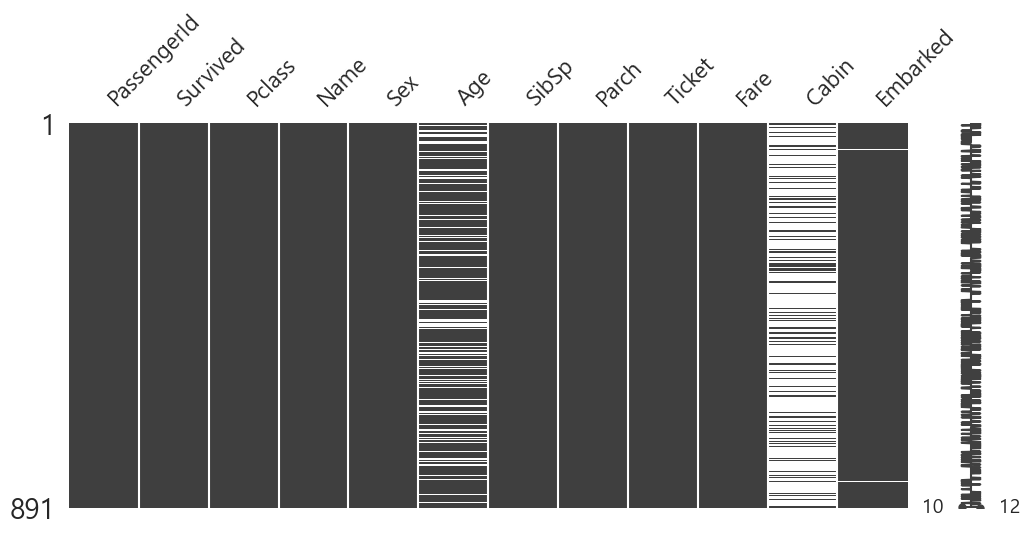

In [5]:
# 결측치 시각화
msno.matrix(df, figsize=(12, 5))
# 분석
# 결측치를 시각화해서 한 눈에 보기에 좋은 라이브러리인 것 같다

<Axes: ylabel='count'>

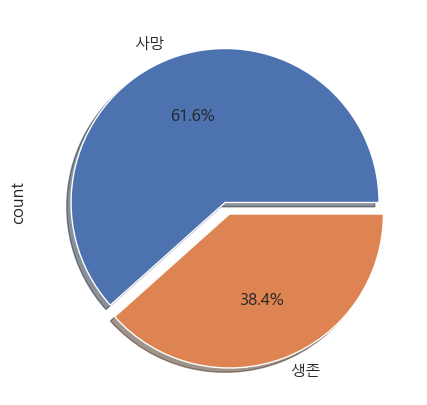

In [6]:
# 가장 중요한 Survived(타겟변수) 분석
df['Survived'].value_counts()
# Survived
# 0    549
# 1    342
# Name: count, dtype: int64

plt.figure(figsize=(8, 5))
labels = ['사망', '생존']
df['Survived'].value_counts().plot.pie(explode=[0, 0.08], 
                                          shadow=True,
                                          autopct='%1.1f%%',
                                          labels=labels)
# 분석
# 사망 비율은 61.6%, 생존 비율은 38.4%로 사망한 탑승객의 수가 더 많은 것이 확인 된다.



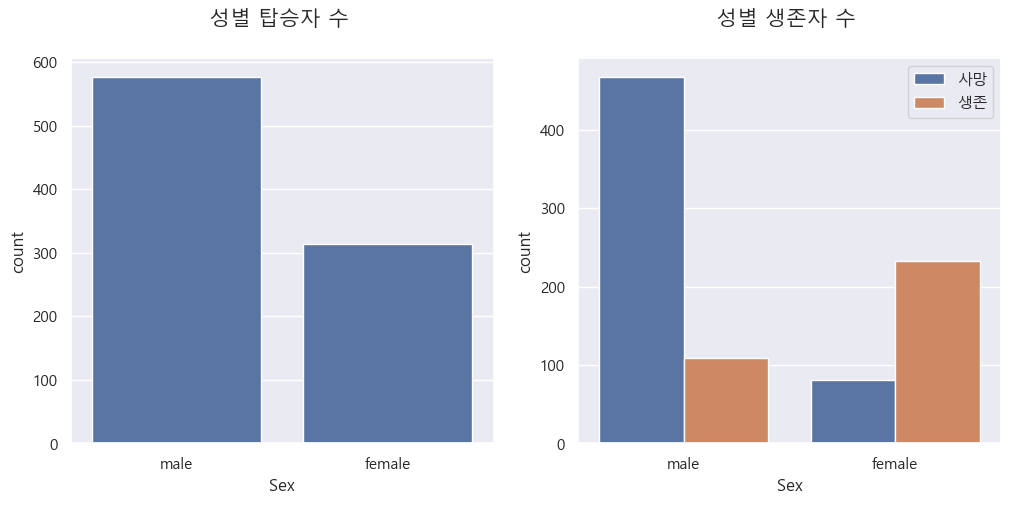

In [7]:
# 성별 및 성별에 따른 생존자
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("성별 탑승자 수 \n", size=15)
sns.countplot(x="Sex", data=df, ax=axes[0])

axes[1].set_title("성별 생존자 수 \n", size=15)
sns.countplot(x="Sex", hue="Survived", data=df, ax=axes[1])
axes[1].legend(labels = ['사망', '생존'])

# 분석 
# 남성의 탑승자 수가 더 많았지만, 여성의 생존자 수가 더 많다.

In [8]:
# 남성 여성 수치 데이타 확인
df[['Sex', 'Survived']].groupby(['Sex'], as_index=True).mean().sort_values(by='Survived', ascending=False)

,Survived
Sex,
female,0.742038
male,0.188908


,Survived
Sex,
female,0.742038
male,0.188908


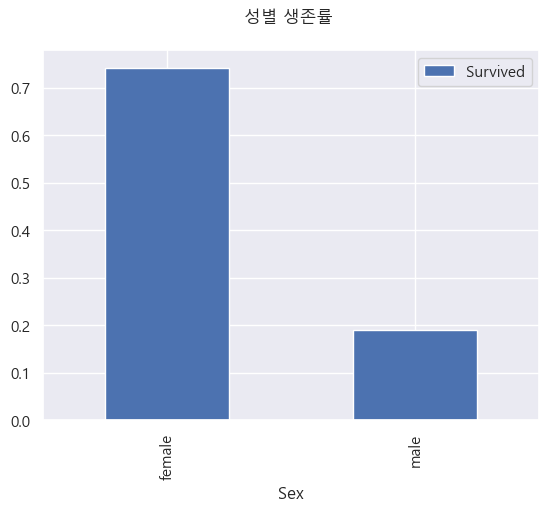

In [9]:
# 성별에 따른 생존률을 비교해보면
sur = df[['Sex', 'Survived']].groupby('Sex').mean().plot.bar()

sur.set_title("성별 생존률 \n")
df[['Sex', 'Survived']].groupby('Sex').mean()

In [10]:
# 티켓 클래스 분석
df[['Pclass', 'Survived']].groupby('Pclass').mean()

# 분석
# 1등석의 생존률은 약 63%, 2등석의 생존률은 약 47.3%, 3등석의 생존률은 약 24.2%이다.
# 3등석 탑승객들이 많이 사망한 것으로 보인다.

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


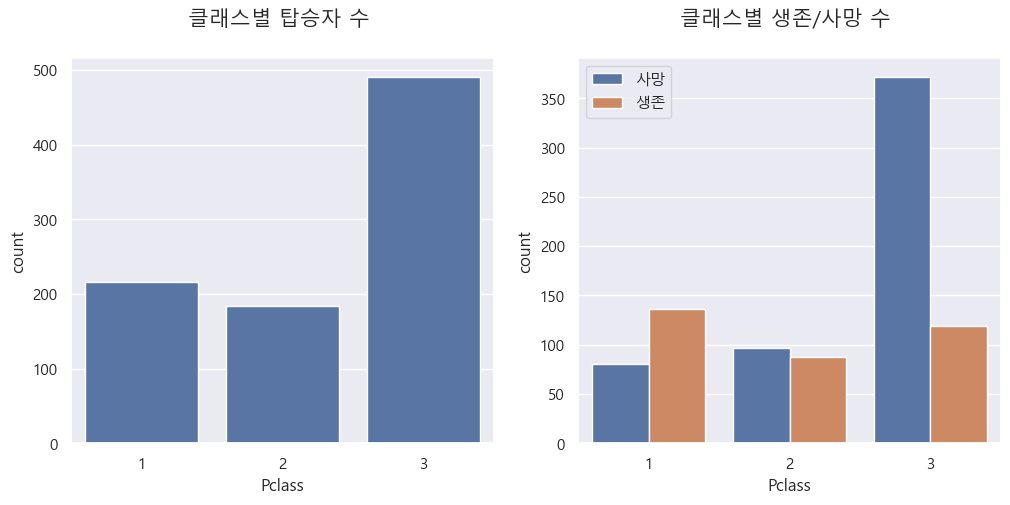

In [11]:
# 티켓 및 티켓에 따른 생존자
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("클래스별 탑승자 수 \n", size=15)
sns.countplot(x="Pclass", data=df, ax=axes[0])

axes[1].set_title("클래스별 생존/사망 수 \n", size=15)
sns.countplot(x="Pclass", hue="Survived", data=df, ax=axes[1])
axes[1].legend(labels = ['사망', '생존'])

# 분석
# 3등석 탑승객이 가장 많고, 3등석 탑승객의 사망 인원수 또한 가장 많다.
# 상대적으로 1등석 탑승객들은 많이 살아남았다.


<Axes: xlabel='Pclass'>

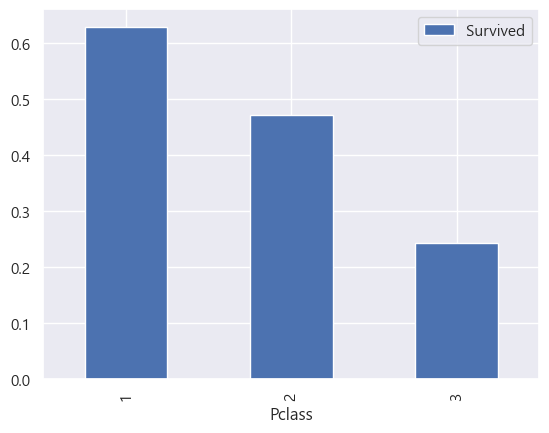

In [12]:
# 각 클래스별 생존률
# 1	0.629630
# 2	0.472826
# 3	0.242363
df[['Pclass', 'Survived']].groupby('Pclass').mean().plot.bar()


In [13]:
# Age 나이 
df['Age'].describe()

# 분석
# 평균 나이가 29세 인걸 확인 할수 있다


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

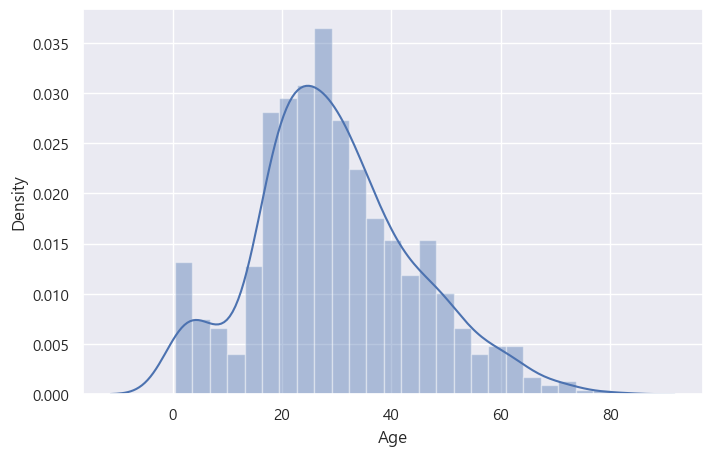

In [14]:
plt.figure(figsize=(8, 5))
sns.distplot(df['Age'], bins=25)

# 분석
# 탑승객들의 나이는 주로 20세와 40세사이 에 분포한다

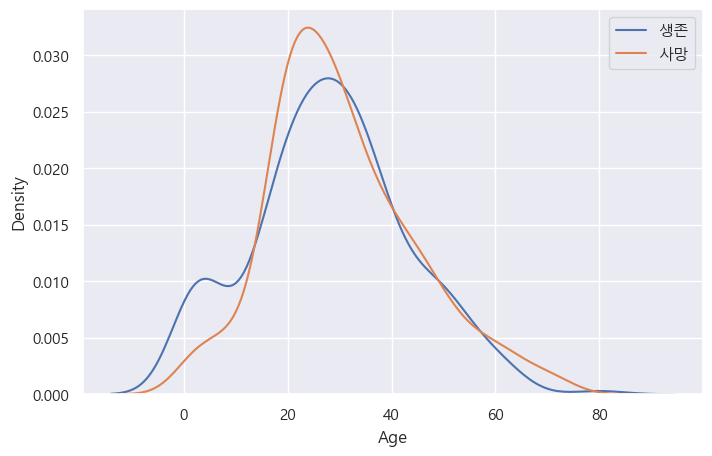

In [15]:
# 나이가 생존여부에 영향을 끼쳤는지 조사

survied = df[df['Survived'] == 1]
dead = df[df['Survived'] == 0]

plt.figure(figsize=(8, 5))
sns.distplot(survied['Age'],  label='생존',bins=25,hist=False)
sns.distplot(dead['Age'], label='사망',bins=25,hist=False)

# 범례 표시
plt.legend()
#분석
# 어린 나이 탑승객들의 생존률이 비교적 높고, 20~30세의 생존률은 비교적 낮아 보인다.

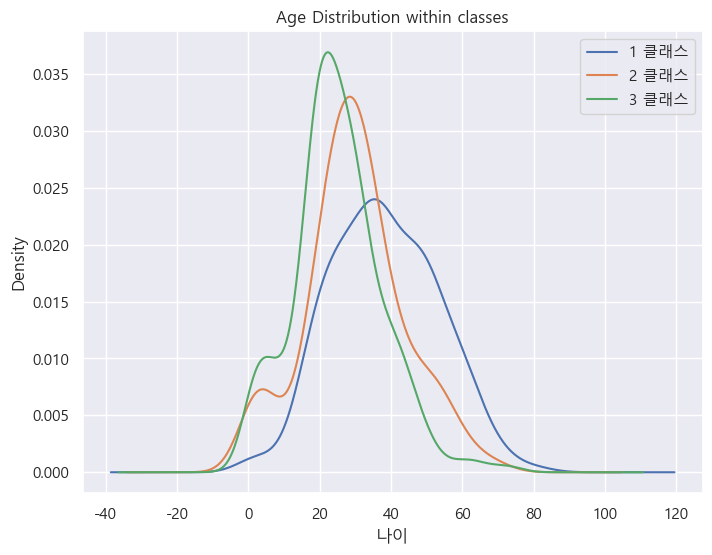

In [16]:
# 나이, 클래스 비교
plt.figure(figsize=(8, 6))
df['Age'][df['Pclass'] == 1].plot(kind='kde')
df['Age'][df['Pclass'] == 2].plot(kind='kde')
df['Age'][df['Pclass'] == 3].plot(kind='kde')

plt.xlabel('나이')
plt.title('Age Distribution within classes')
plt.legend(['1 클래스', '2 클래스', '3 클래스'])

# 분석
# class가 높을수록 나이 많은 사람의 비중이 커짐


<Axes: title={'center': 'Parch별 생존여부'}, xlabel='Parch', ylabel='count'>

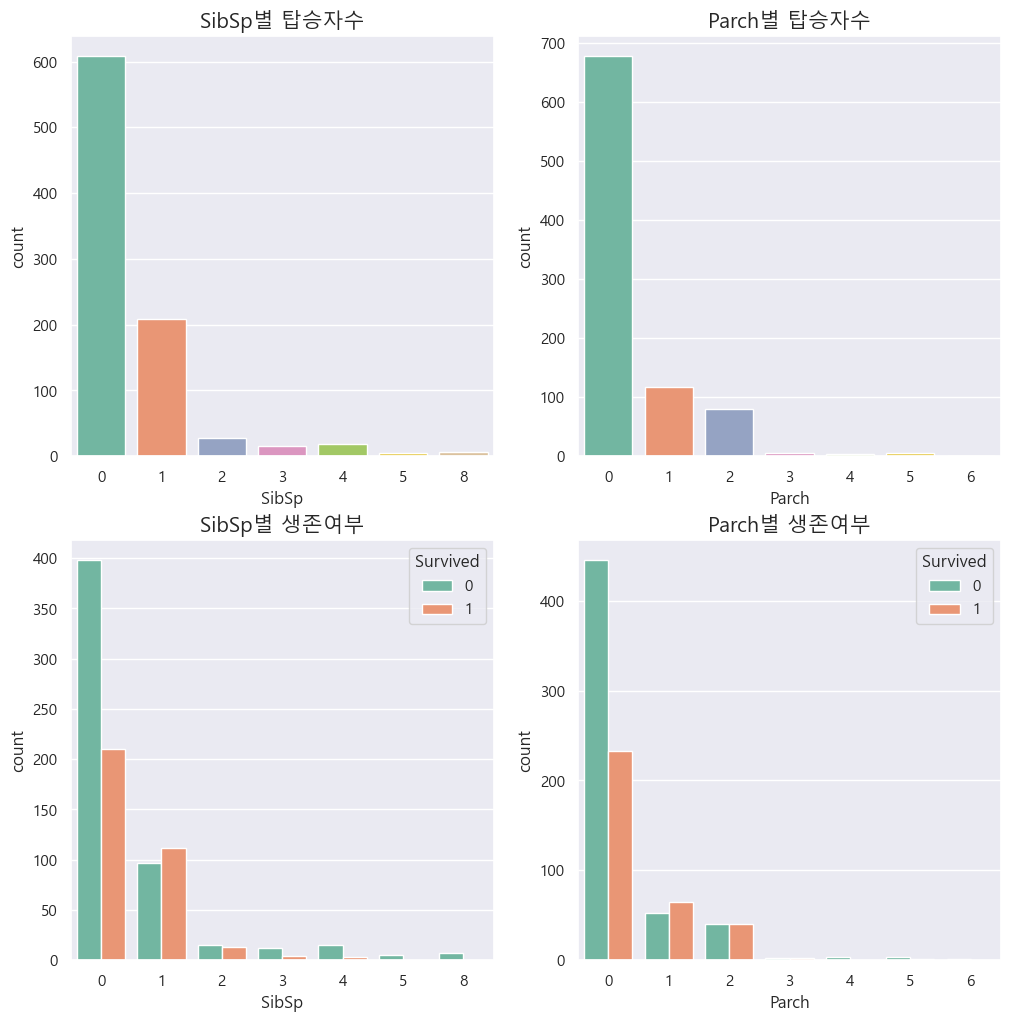

In [17]:
#함께 탑승한 가족의 수( SibSp, Parch )
# SibSp - 함께 탑승한 형제자매, 배우자 수 총합
# Parch - 함께 탑승한 부모, 자녀 수 총합

fig, axes = plt.subplots(2,2 ,figsize=(12,12))

axes[0][0].set_title("SibSp별 탑승자수",size=15)
sns.countplot(x="SibSp",data=df,ax=axes[0][0],palette="Set2")

axes[0][1].set_title("Parch별 탑승자수",size=15)
sns.countplot(x="Parch",data=df,ax=axes[0][1],palette="Set2")

# 생존여부
axes[1][0].set_title("SibSp별 생존여부",size=15)
sns.countplot(x="SibSp",hue="Survived" ,data=df,ax=axes[1][0],palette="Set2")

axes[1][1].set_title("Parch별 생존여부",size=15)
sns.countplot(x="Parch",hue="Survived",data=df,ax=axes[1][1],palette="Set2")

# 분석
# 혼자 탑승한 탑승객이 가장 많다.
#수


In [18]:
# 수치 확인
print(df[['SibSp','Survived']].groupby(['SibSp']).mean())
print(df[['Parch','Survived']].groupby(['Parch']).mean())

#분석
# SibSp의 경우 혼자 탑승한 사람보다 , 3명 4명 탑승한 탑승객들의 사망률이 가장 높다          
# Parch의 경우  부모 자녀 없이 혼자 탑승한 사람의 사망률이 가장 높다.


       Survived
SibSp          
0      0.345395
1      0.535885
2      0.464286
3      0.250000
4      0.166667
5      0.000000
8      0.000000
       Survived
Parch          
0      0.343658
1      0.550847
2      0.500000
3      0.600000
4      0.000000
5      0.200000
6      0.000000


In [19]:
#Family - SibSp(형제 자매) + Parch(부모, 자녀)
#SibSp와 Parch를 합하면 Family 가 될 것입니다. Family 로 합쳐서 분석해봅시다.

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 # 자신을 포함해야하니 1을 더합니다
print("Minimum size of Family: ", df['FamilySize'].min())

df.head(100)

Minimum size of Family:  1


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",male,NaN,0,0,374910,8.0500,NaN,S,1
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C,1
97,98,1,1,"Greenfield, Mr. William Bertram",male,23.0,0,1,PC 17759,63.3583,D10 D12,C,2
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",female,34.0,0,1,231919,23.0000,NaN,S,2


Text(0.5, 1.02, '(2) Survived countplot depending on FamilySize')

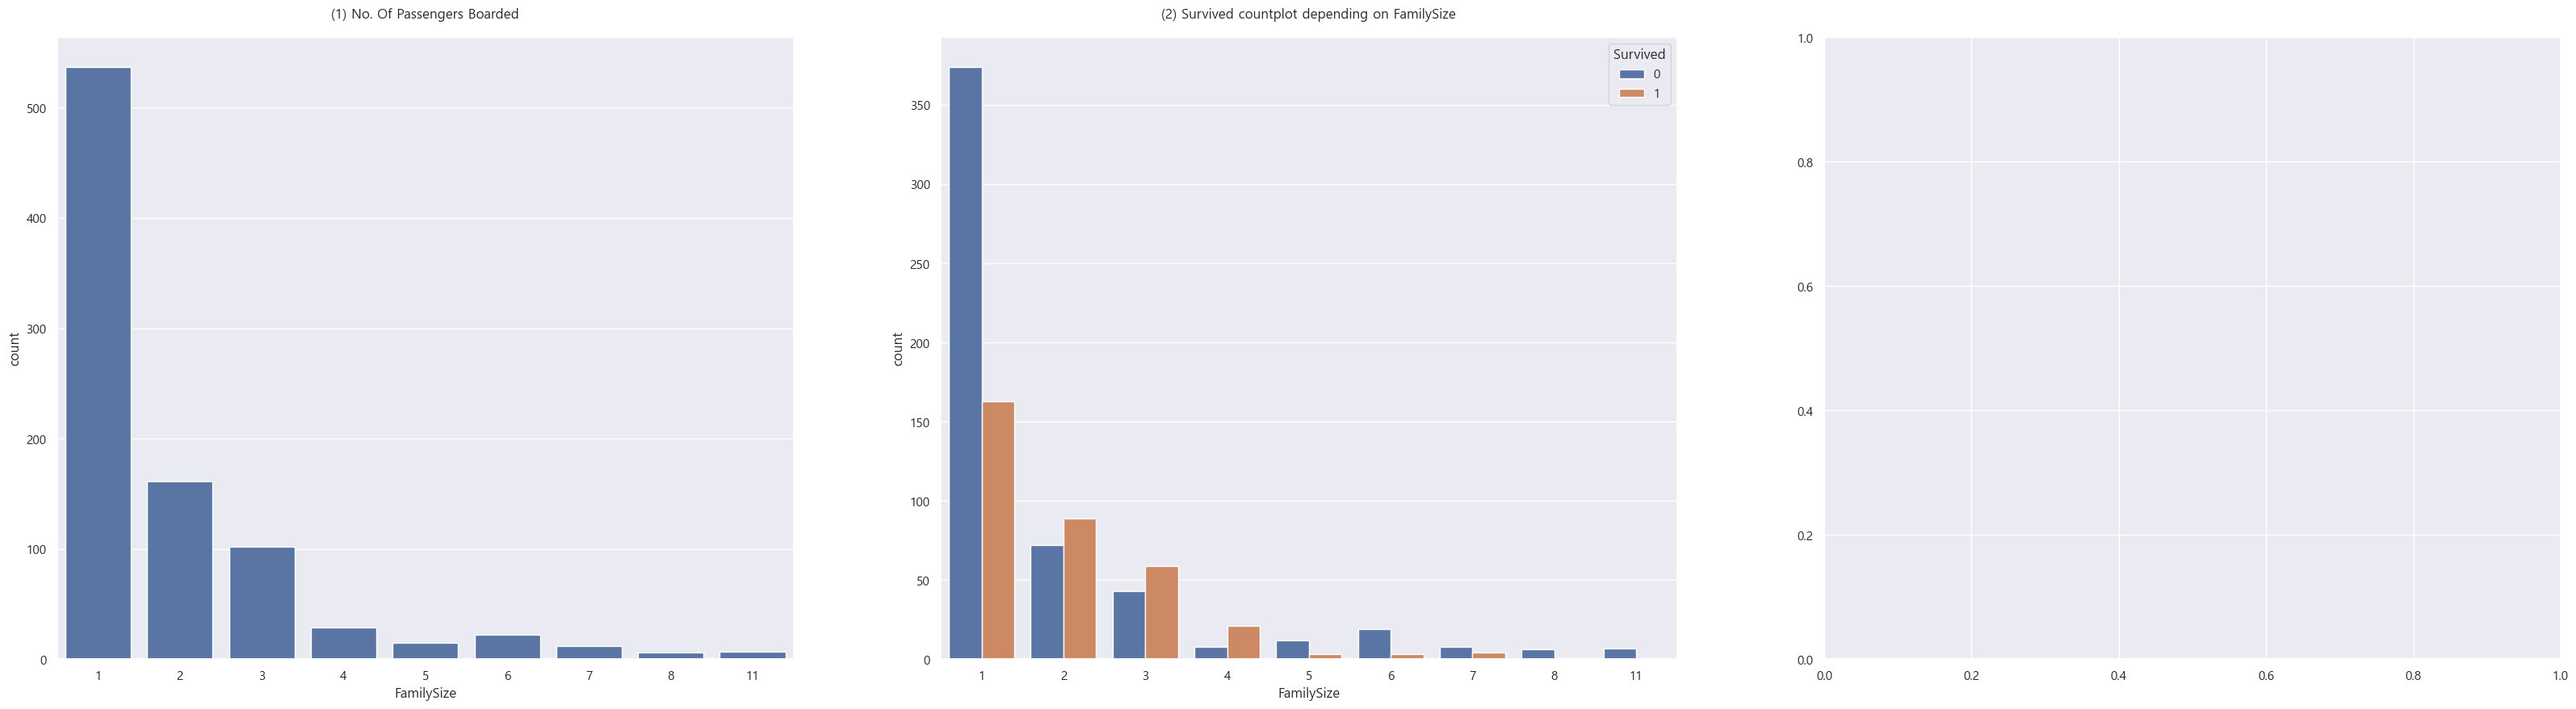

In [20]:
f,ax=plt.subplots(1, 3, figsize=(40,10))
sns.countplot(x=df['FamilySize'], data=df, ax=ax[0])
ax[0].set_title('(1) No. Of Passengers Boarded', y=1.02)

# 분석 
#(1)그래프. 1인 탑승객이 500명이 넘는다. 가장 많은 가족 수는 11명이다.


sns.countplot(x=df['FamilySize'], hue='Survived', data=df, ax=ax[1])
ax[1].set_title('(2) Survived countplot depending on FamilySize',  y=1.02)

#(2) 2 인 3인 4인 가족은 사망률보다 생존률이 높고, 5인 이상 가족들은 생존률이 극히 떨어짐을 확인할수 있다.

In [21]:
# 가족수에 따른 생존률 수치확인
df[['FamilySize','Survived']].groupby(['FamilySize']).mean()

# 분석
# 4인 가족의 경우 특이하게 생존률이 70% 가 넘었음

,Survived
FamilySize,
1,0.303538
2,0.552795
3,0.578431
4,0.724138
5,0.200000
6,0.136364
7,0.333333
8,0.000000
11,0.000000


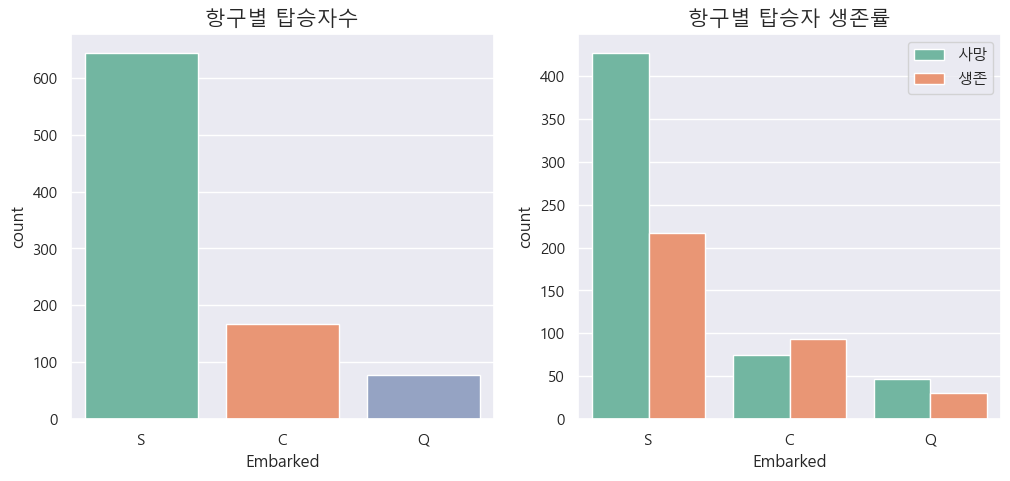

In [22]:
# 탑승항구
# Southampton (S) – 영국 사우샘프턴
# Cherbourg (C) – 프랑스 셰르부르
# Queenstown (Q) – 아일랜드 퀸스타운 (현재는 코브, Cobh)

fig, axes = plt.subplots(1,2 ,figsize=(12,5))

axes[0].set_title("항구별 탑승자수",size=15)
sns.countplot(x="Embarked",data=df,ax=axes[0],palette="Set2")
# 분석
# 탑승객이 많은 순서는 S>C>Q 순이다

axes[1].set_title("항구별 탑승자 생존률",size=15)
sns.countplot(x="Embarked",hue="Survived" ,data=df,ax=axes[1],palette="Set2")
axes[1].legend(labels = ['사망', '생존'])
# 분석
# S항구 탑승객이 가장 많았으며 사망한 인원 역시 S항구 탑승객이 가장 많다.


In [23]:
# 수치로 확인 
df[['Embarked', 'Survived']].groupby(['Embarked']).mean()


# 분석
# C항구 생존률이 50% 가 넘음

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.336957


<Axes: >

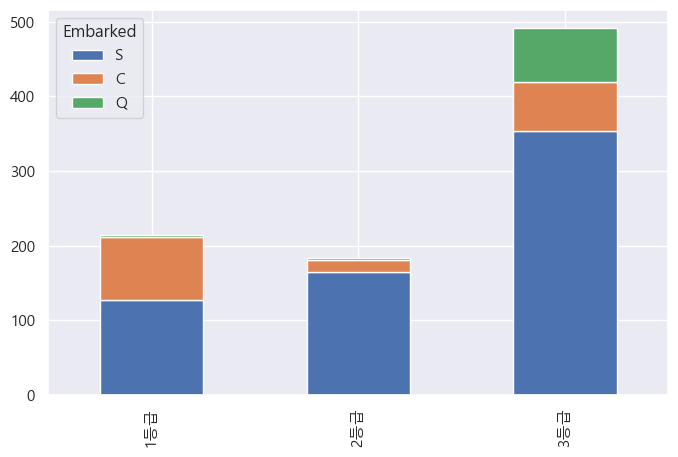

In [ ]:
# 항구별로 사망률 차이가 나는지 확인 하기 위해서, 탑승객의 티켓 클래스와 동승자를 확인 해봄

class1 =  df[df['Pclass'] == 1]['Embarked'].value_counts()
class2 =  df[df['Pclass'] == 2]['Embarked'].value_counts()
class3 =  df[df['Pclass'] == 3]['Embarked'].value_counts()

df_class = pd.DataFrame([class1,class2,class3])
df_class.index = ['1등급','2등급','3등급']

fig, ax = plt.subplots(figsize=(8,5))
df_class.plot(kind='bar',stacked=True,ax=ax)

# 분석
# 3등석에 S항구 탑승객들이 많은것을 확인 할수 있다.
# 3등석에 사망률이 가장 높았듯이, 3등석에 S항구 탑승객들이 많이 탑승해서, S항구 탑승객들의 사망률이 높아 보인다.
# C항구의 경우 사망자 보다 생존자가 더 많았음. C항구에서 1등석 탑승객이 많았던 것도 영향이 있었던 것으로 보인다.


<Axes: xlabel='Parch', ylabel='count'>

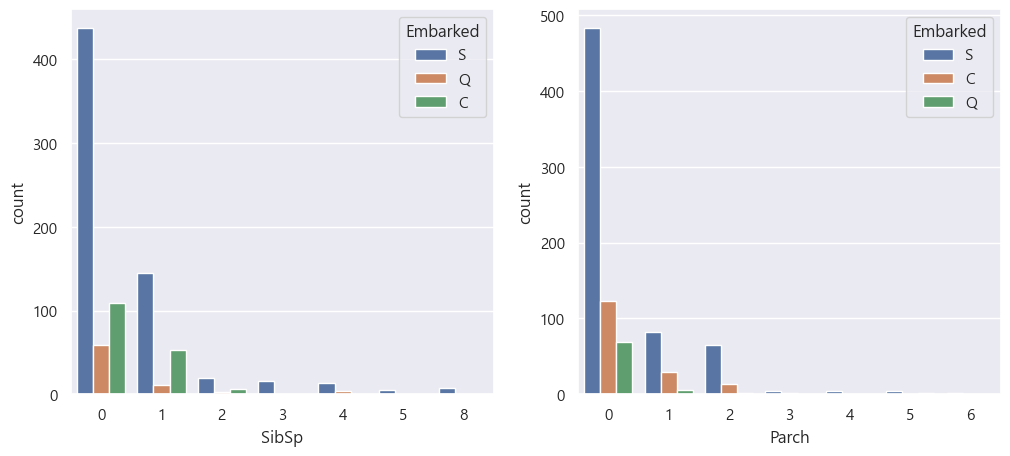

In [25]:
# 항구별 탑승객들의 동승자(부모 자매 형제)

fig, ax = plt.subplots(1,2 ,figsize=(12,5))

sns.countplot(data=df,x="SibSp",hue='Embarked',ax=ax[0])
sns.countplot(data=df,x="Parch",hue='Embarked',ax=ax[1])

# 분석
# 혼자 탑승한 탑승객수도 S 항구 탑승객이 압도적으로 많았다. 그래서 사망률 또한 S 항구가 높다.


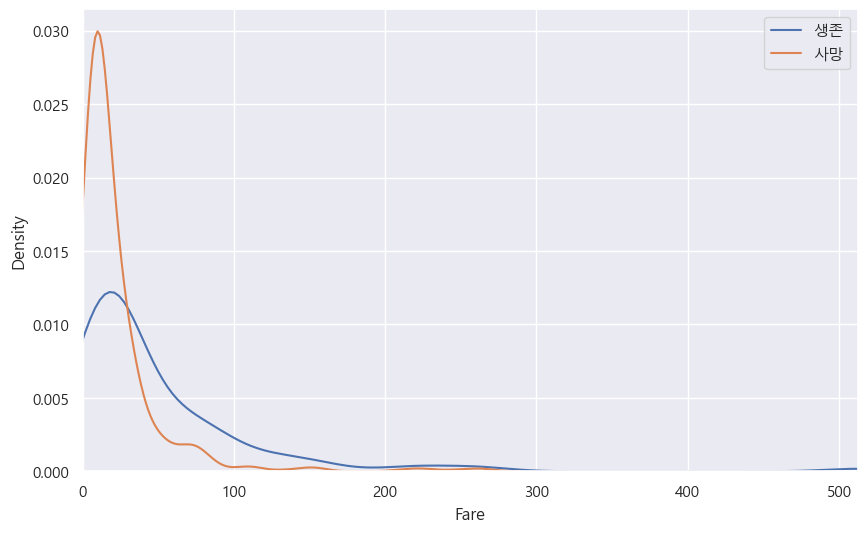

In [26]:
# 탑승금액

fig, ax = plt.subplots(figsize=(10,6))
# 분포 확인
sns.kdeplot(df[df['Survived']==1]['Fare'], ax=ax)
sns.kdeplot(df[df['Survived']==0]['Fare'], ax=ax)

# 축범위
# 축 범위
ax.set(xlim=(0, df['Fare'].max()))
ax.legend(['생존', '사망'])

# 분석
# 탑승금액이 적은 쪽이 사망률이 높은것이 확인된다.
# 탑승 클래스/탑승 금액에 따라 생존 여부에 영향을 끼치는 것으로 생각된다.



Text(0.5, 1.0, 'Fares in Pclass 3')

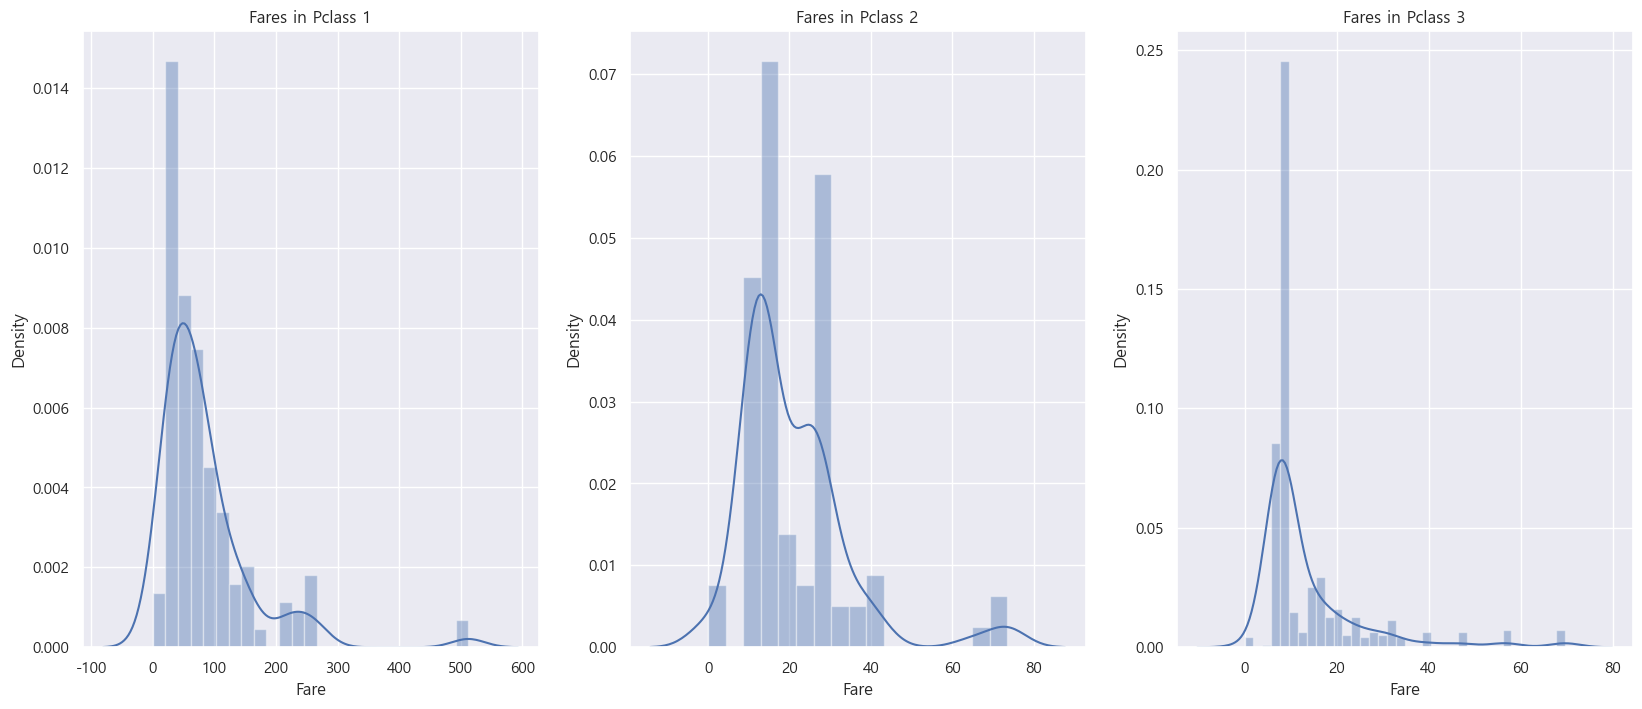

In [27]:
# 요금

f,ax=plt.subplots(1,3,figsize=(20,8))
sns.distplot(df[df['Pclass']==1].Fare,ax=ax[0])
ax[0].set_title('Fares in Pclass 1')

sns.distplot(df[df['Pclass']==2].Fare,ax=ax[1])
ax[1].set_title('Fares in Pclass 2')

sns.distplot(df[df['Pclass']==3].Fare,ax=ax[2])
ax[2].set_title('Fares in Pclass 3')

#Pclass = 1의 운임은 대체로 20 이상으로 많이 분포하고 있고 500까지 범위가 굉장히 넓다, 비싸게 주고 탄사람도 많음
#Pclass = 2의 운임은 쌍봉형태인데, 10, 30 정도에서 쌍봉을 이루고 있음
#Pclass = 3의 운임도 의외로 비싸게 주고 탄 사람도 있었는데 대체로 10정도의 운임을 많이 냈음

In [28]:
# 1. 문제
# 한살 미만 영유아는 몇명 이며 생존률은?
# df[(df['Age'] < 1) & (df['Survived'] == 1)]